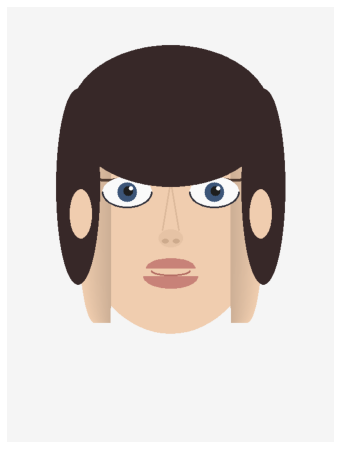

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# 画布 600×800，浅色背景
img = np.ones((800, 600, 3), dtype=np.uint8) * 245
cx, cy = 300, 380  # 脸部中心

# ========== 1. 脸部基底 + 肤色渐变 ==========
# 主肤色（黄种人BGR：偏暖调）
skin_base = (175, 205, 240)
# 脸部椭圆轮廓
cv2.ellipse(img, (cx, cy), (170, 220), 0, 0, 360, skin_base, -1)

# 脸部两侧阴影，模拟脸部立体感
for i in range(30):
    alpha = i / 30
    color = (int(175 - 25*alpha), int(205 - 30*alpha), int(240 - 35*alpha))
    cv2.ellipse(img, (cx - 140 + i, cy), (30 - i, 200), 0, 0, 360, color, -1)
    cv2.ellipse(img, (cx + 140 - i, cy), (30 - i, 200), 0, 0, 360, color, -1)

# 额头高光
for i in range(20):
    alpha = i / 20
    color = (int(185 + 10*alpha), int(215 + 10*alpha), int(245 + 10*alpha))
    cv2.ellipse(img, (cx, cy - 160 + i), (100, 20 - i), 0, 0, 360, color, -1)

# ========== 2. 眉毛 ==========
brow_color = (50, 60, 80)
# 左眉
cv2.ellipse(img, (cx - 80, cy - 80), (55, 12), -15, 0, 180, brow_color, 3)
# 右眉
cv2.ellipse(img, (cx + 80, cy - 80), (55, 12), 15, 0, 180, brow_color, 3)

# ========== 3. 眼睛 ==========
eye_white = (250, 250, 250)
iris_color = (120, 85, 60)  # 棕褐色虹膜
pupil_color = (30, 30, 30)
highlight = (255, 255, 255)

# 左眼
cv2.ellipse(img, (cx - 80, cy - 40), (45, 28), 0, 0, 360, eye_white, -1)
cv2.circle(img, (cx - 80, cy - 40), 18, iris_color, -1)
cv2.circle(img, (cx - 78, cy - 42), 9, pupil_color, -1)
cv2.circle(img, (cx - 73, cy - 47), 4, highlight, -1)
# 上眼睑弧线（改用ellipse画上半圆弧：start=0 end=180）
cv2.ellipse(img, (cx - 80, cy - 40), (45, 28), 0, 0, 180, (60, 50, 50), 2)

# 右眼
cv2.ellipse(img, (cx + 80, cy - 40), (45, 28), 0, 0, 360, eye_white, -1)
cv2.circle(img, (cx + 80, cy - 40), 18, iris_color, -1)
cv2.circle(img, (cx + 82, cy - 42), 9, pupil_color, -1)
cv2.circle(img, (cx + 87, cy - 47), 4, highlight, -1)
# 上眼睑弧线
cv2.ellipse(img, (cx + 80, cy - 40), (45, 28), 0, 0, 180, (60, 50, 50), 2)

# ========== 4. 鼻子 ==========
nose_shadow = (155, 185, 220)
# 鼻梁
cv2.line(img, (cx, cy - 60), (cx - 15, cy + 30), nose_shadow, 2)
cv2.line(img, (cx, cy - 60), (cx + 15, cy + 30), nose_shadow, 2)
# 鼻头
cv2.ellipse(img, (cx, cy + 45), (22, 16), 0, 0, 360, (165, 195, 230), -1)
# 鼻孔
cv2.ellipse(img, (cx - 10, cy + 50), (6, 4), 0, 0, 360, (140, 170, 205), -1)
cv2.ellipse(img, (cx + 10, cy + 50), (6, 4), 0, 0, 360, (140, 170, 205), -1)

# ========== 5. 嘴唇 ==========
lip_color = (120, 130, 200)
lip_dark = (100, 110, 180)
# 上唇
cv2.ellipse(img, (cx, cy + 100), (45, 18), 0, 180, 360, lip_color, -1)
# 下唇
cv2.ellipse(img, (cx, cy + 115), (50, 22), 0, 0, 180, lip_color, -1)
# 唇缝
cv2.ellipse(img, (cx, cy + 105), (35, 8), 0, 0, 180, lip_dark, 2)

# ========== 6. 头发 ==========
hair_color = (40, 40, 55)
# 头发主体
cv2.ellipse(img, (cx, cy - 180), (185, 130), 0, 0, 360, hair_color, -1)
# 两侧头发
cv2.ellipse(img, (cx - 170, cy - 50), (40, 180), 0, 0, 360, hair_color, -1)
cv2.ellipse(img, (cx + 170, cy - 50), (40, 180), 0, 0, 360, hair_color, -1)
# 刘海
cv2.ellipse(img, (cx - 60, cy - 190), (70, 40), -20, 0, 360, hair_color, -1)
cv2.ellipse(img, (cx + 60, cy - 190), (70, 40), 20, 0, 360, hair_color, -1)

# ========== 7. 耳朵 ==========
cv2.ellipse(img, (cx - 165, cy), (20, 45), 0, 0, 360, skin_base, -1)
cv2.ellipse(img, (cx + 165, cy), (20, 45), 0, 0, 360, skin_base, -1)

# ========== 显示 ==========
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 8))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()